# imports

In [1]:
!pip install -q langchain-groq langgraph pymupdf langchain_community langchain_chroma "unstructured[pdf]"
!apt install poppler-utils tesseract-ocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 11.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 4.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter
from google.colab import userdata
import os
from uuid import uuid4
from copy import deepcopy

from unstructured.documents.elements import NarrativeText, Title, Image, Table
import fitz
import re
from unstructured.partition.pdf import partition_pdf
from pypdf import PdfWriter, PdfReader


os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
llm = ChatGroq(model="openai/gpt-oss-120b")
llm_summariser = ChatGroq(model="llama-3.1-8b-instant")
llm_image_summariser = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")


from langchain.vectorstores import Chroma
from langchain.storage import InMemoryStore
from langchain.schema.document import Document
from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain_community.embeddings import HuggingFaceEmbeddings


from typing import Annotated, Literal, List
from typing_extensions import TypedDict
from operator import add
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage, AIMessage

import json
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from langgraph.checkpoint.memory import InMemorySaver

from langchain_core.tools import InjectedToolArg, tool, InjectedToolCallId
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.runnables.config import RunnableConfig

In [3]:
os.environ["LANGSMITH_API_KEY"] = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING_V2"] = "true"
os.environ["LANGSMITH_PROJECT"] = "rag_swarm"

# docstore

In [4]:
def get_summary(text):
    messages = [SystemMessage("""
    Your job is to summarize the given raw text. Chunks of raw text are given to you and you have to analyze properly what all is contained in them.
    Pay special attention to table captions, image captions and formulas and include them in your summaries.
    You can skip the factual numeric details but you must tell what all is contained in the given chunk of raw text.

    IMPORTANT: Only output the summary and no boilerplate text like "Here's your summary"
    """)]
    messages.append(HumanMessage(f"Here is the raw text: {text}"))
    res = llm_summariser.invoke(messages)

    return res.content

def get_image_summary(image_data):
    messages = [SystemMessage("""
    Your job is to summarize the given image.
    If the image is graph, extract relevant details like graph title, axis labels, maximum values etc.
    If the image is a diagram or illustration extract important components and make proper analysis in them.
    Include keywords in your summary that will help map the summary easily to the image
    IMPORTANT: Only output the summary and no boilerplate text like "Here's your summary"
    """)]
    messages.append(HumanMessage(content=[
        {
            "type": "image_url",
            "image_url": {"url": f"data:image/jpeg;base64,{image_data}"},
        }
    ]))
    res = llm_image_summariser.invoke(messages)

    return res.content

def get_table_summary(table_data):
    messages = [SystemMessage("""
    Your job is to summarize the given table. The table is in HTML format. Describe the table properly, include keywords that help in telling what all data is contained in the table.
    Make sure to include the names of column headings or row headings as necessary. Properly analyze the table and return a dense yet concise summary.
    IMPORTANT: Only output the summary and no boilerplate text like "Here's your summary"
    """)]
    messages.append(HumanMessage(f"Here is the table in HTML format: {table_data}"))
    res = llm_summariser.invoke(messages)

    return res.content

In [5]:
class Docstore():
    def __init__(self, pdf_path):
        self.pdf_path = pdf_path


    def get_doc_hierarchy(self):

        def find_toc_pages(doc, search_limit=20):
            toc_pages = []
            for i in range(min(len(doc), search_limit)):
                page = doc[i]
                text = page.get_text("text", sort=True).lower()
                if "contents" in text or "table of contents" in text:
                    toc_pages.append(i)
            return toc_pages

        def toc_raw_to_hierarchy(toc_raw):
            messages = [SystemMessage("""
                You are a document hierarchy generator. Your task is to generate a python dictionary.
                You are given the raw text on the table of contents page of a document.
                analyze it properly and structure it into a neat json object.
                The document hierarchy is only needed till depth level 2. the schema of the json object is as follows
                {
                    "section_name": str
                    "section_children": list[str]
                }
                You must follow this schema.
                YOur output should be json object and it will be evaluated as it is so do not give boilerplate text or backticks
                """)]
            messages.append(HumanMessage("here is the raw text on the table of contents page of the document"))
            messages.append(HumanMessage(toc_raw))

            res = llm.with_structured_output(method="json_mode").invoke(messages)
            return res

        def toc_to_hierarchy(toc):
            hierarchy = []
            for i in range(len(toc)):
                if toc[i][0] == 1:
                    new_section = {
                        "section_name": toc[i][1],
                        "section_children": []
                    }
                    new_section_children = []
                    for j in range(i+1, len(toc)):
                        if toc[j][0] == 2:
                            new_section_children.append(toc[j][1])
                        elif toc[j][0] == 1:
                            break
                    new_section["section_children"] = new_section_children
                    hierarchy.append(new_section)
            return hierarchy

        doc = fitz.open(self.pdf_path)
        toc = doc.get_toc()
        toc_pages = find_toc_pages(doc)
        if toc:
            return toc_to_hierarchy(toc), toc_pages


        if toc_pages:
            toc_raw = ""
            for i in toc_pages:
                toc_raw += doc[i].get_text("text")
            return toc_raw_to_hierarchy(toc_raw), toc_pages

        return None

    def create_headings_store(self):

        self.low_res_elements = partition_pdf(
            filename="report.pdf",
            strategy="fast"
        )
        self.doc_hierarchy, self.toc_pages = self.get_doc_hierarchy()

        doc_hierarchy = deepcopy(self.doc_hierarchy)
        current_section_idx = 0
        current_section_chunks = []

        if self.toc_pages:
            last_toc_page = self.toc_pages[-1]
            split_idx = next(
                (i for i, x in enumerate(elements) if x.metadata.page_number == last_toc_page + 2),
                None
            )
            elements = elements[split_idx:]

        next_section_name = (
            doc_hierarchy[current_section_idx + 1]["section_name"]
            if current_section_idx + 1 < len(doc_hierarchy)
            else None
        )

        for e in self.low_res_elements:
            if next_section_name and isinstance(e, Title) and next_section_name in e.text:
                doc_hierarchy[current_section_idx]["section_chunks"] = current_section_chunks
                current_section_chunks = [e]
                current_section_idx += 1
                next_section_name = (
                    doc_hierarchy[current_section_idx + 1]["section_name"]
                    if current_section_idx + 1 < len(doc_hierarchy)
                    else None
                )
            else:
                current_section_chunks.append(e)

        doc_hierarchy[current_section_idx]["section_chunks"] = current_section_chunks


        leaf_sections = []
        for section in doc_hierarchy:
            if len(section["section_children"]) == 0:
                leaf_sections.append({
                    "section_id": str(uuid4()),
                    "section_name": section["section_name"],
                    "section_chunks": section["section_chunks"]
                })
            else:
                current_subsec_chunks = []
                split_idx = 0
                for i in range(len(section["section_chunks"])):
                    e = section["section_chunks"][i]
                    if isinstance(e, Title) and section["section_children"][0] in e.text:
                        leaf_sections.append({
                            "section_id": str(uuid4()),
                            "section_name": section["section_name"],
                            "section_chunks": current_subsec_chunks
                        })
                        split_idx = i
                        break
                    else:
                        current_subsec_chunks.append(e)

                section["section_chunks"] = section["section_chunks"][split_idx:]
                current_subsec_idx = 0
                current_subsec_chunks = []
                next_subsec_name = (
                    section["section_children"][current_subsec_idx + 1]
                    if current_subsec_idx + 1 < len(section["section_children"])
                    else None
                )
                for e in section["section_chunks"]:
                    if next_subsec_name and isinstance(e, Title) and next_subsec_name in e.text:
                        leaf_sections.append({
                            "section_id": str(uuid4()),
                            "section_name": section["section_children"][current_subsec_idx],
                            "section_chunks": current_subsec_chunks
                        })

                        current_subsec_chunks = [e]
                        current_subsec_idx += 1
                        next_subsec_name = (
                            section["section_children"][current_subsec_idx + 1]
                            if current_subsec_idx + 1 < len(section["section_children"])
                            else None
                        )
                    else:
                        current_subsec_chunks.append(e)

                leaf_sections.append({
                    "section_id": str(uuid4()),
                    "section_name": section["section_children"][current_subsec_idx],
                    "section_chunks": current_subsec_chunks
                })

        self.leaf_sections = leaf_sections

        text_splitter = RecursiveCharacterTextSplitter(chunk_size=2500)

        summaries = {}

        for sec in leaf_sections:
            sec_text = []
            for sec_chunk in sec["section_chunks"]:
                if isinstance(sec_chunk, NarrativeText):
                    sec_text.append(sec_chunk.text)
            if len(sec_text) == 0:
                continue
            raw_sec_text = "\n".join(sec_text)
            sec_text_chunks = text_splitter.split_text(raw_sec_text)
            sec_summaries = []
            for sec_chunk in sec_text_chunks:
                sec_summaries.append(get_summary(sec_chunk))

            if len(sec_summaries) > 1:
                sec_summary = get_summary("\n".join(sec_summaries))
            else:
                sec_summary = sec_summaries[0]

            summaries[sec["section_id"]] = sec_summary

        embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

        heading_store = Chroma(collection_name="heading_store", embedding_function=embeddings)

        # The storage layer for the parent documents
        store = InMemoryStore()
        id_key = "section_id"

        # The retriever (empty to start)
        heading_retriever = MultiVectorRetriever(
            vectorstore=heading_store,
            docstore=store,
            id_key=id_key,
        )
        heading_retriever.vectorstore.add_documents([
            Document(
                page_content=sec_sum,
                metadata={id_key: sec_id}
            )
            for sec_id, sec_sum in summaries.items()
        ])
        heading_retriever.docstore.mset([
            (sec["section_id"], sec)
            for sec in leaf_sections
        ])
        self.heading_retriever = heading_retriever
        self.page_cache = {}
        return heading_retriever

    def create_query_retriever(self, relevant_page_numbers):
        if not hasattr(self, "page_cache"):
            self.page_cache = {}

        pages_not_cached = []
        for page_number in relevant_page_numbers:
            if page_number not in self.page_cache:
                pages_not_cached.append(page_number)
        if len(pages_not_cached) != 0:
            writer = PdfWriter()
            input_pdf  = PdfReader("report.pdf")
            for i in pages_not_cached:
                writer.add_page(input_pdf.pages[i-1])

            batch_filename = 'elements.pdf'
            with open(batch_filename, 'wb') as output_file:
                writer.write(output_file)

            high_res_pages = partition_pdf(
                filename="elements.pdf",
                strategy="hi_res",
                extract_image_block_types=["Image"],
                extract_image_block_to_payload=True,
                infer_table_structure=True
            )

            newly_cached_pages = [[] for _ in pages_not_cached]
            for c in high_res_pages:
                newly_cached_pages[c.metadata.page_number - 1].append(c)

            for i in range(len(newly_cached_pages)):
                image_store = []
                table_store = []
                raw_text_store = []
                for c in newly_cached_pages[i]:
                    if isinstance(c, Image):
                        image_store.append({
                            "doc_id": str(uuid4()),
                            "doc_type": "image",
                            "image_data": c.metadata.image_base64,
                            "image_summary": get_image_summary(c.metadata.image_base64)
                        })
                    elif isinstance(c, Table):
                        table_store.append({
                            "doc_id": str(uuid4()),
                            "doc_type": "table",
                            "table_data": c.metadata.text_as_html,
                            "table_summary": get_table_summary(c.metadata.text_as_html)
                        })
                    else:
                        raw_text_store.append(c.text)


                    raw_text = "\n".join(raw_text_store)
                    text_splitter = RecursiveCharacterTextSplitter(chunk_size=2500)
                    raw_text_store = text_splitter.split_text(raw_text)
                    text_store = [{
                            "doc_id": str(uuid4()),
                            "doc_type": "text",
                            "text_data": t
                        } for t in raw_text_store]

                    new_cache = {
                        "high_res_chunks": newly_cached_pages[i],
                        "image_store": image_store,
                        "table_store": table_store,
                        "text_store": text_store
                    }
                self.page_cache[pages_not_cached[i]] = new_cache

        embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
        query_store = Chroma(collection_name="query_store", embedding_function=embeddings)
        query_doc_store = InMemoryStore()
        id_key="doc_id"

        query_retriever = MultiVectorRetriever(
            vectorstore=query_store,
            docstore=query_doc_store,
            id_key=id_key,
        )
        image_for_query = []
        table_for_query = []
        text_for_query = []

        for page in relevant_page_numbers:
            image_for_query += self.page_cache[page]["image_store"]
            table_for_query += self.page_cache[page]["table_store"]
            text_for_query += self.page_cache[page]["text_store"]

        if image_for_query:
            query_retriever.vectorstore.add_documents([
                Document(
                    page_content=image["image_summary"],
                    metadata={id_key: image["doc_id"], "doc_type": "image"}
                )
                for image in image_for_query
            ])
            query_retriever.docstore.mset([
                (image["doc_id"], image)
                for image in image_for_query
            ])

        if table_for_query:
            query_retriever.vectorstore.add_documents([
                Document(
                    page_content=table["table_summary"],
                    metadata={id_key: table["doc_id"], "doc_type": "table"}
                )
                for table in table_for_query
            ])
            query_retriever.docstore.mset([
                (table["doc_id"], table)
                for table in table_for_query
            ])

        if text_for_query:
            query_retriever.vectorstore.add_documents([
                Document(
                    page_content=text["text_data"],
                    metadata={id_key: text["doc_id"], "doc_type": "text"}
                )
                for text in text_for_query
            ])
            query_retriever.docstore.mset([
                (text["doc_id"], text)
                for text in text_for_query
            ])

        return query_retriever

# Handoff tool

In [6]:
handoff_tool_args = """
"reasoning": {
    "description": "a short yet descriptive log of all of your reasoning",
    "type": "string"
},
"destination": {
    "description": "the name of the agent you want to handoff the task to.",
    "type": "string",
    "enum": [
        "InfoAgent",
        "MathCodingAgent",
        "SummarizerAgent"
    ]
},
"agent_args": {
    "description": "the arguments to pass to the agent.",
    "type": "string"
}
"""

In [7]:
@tool(return_direct=True)
def handoff_tool(
    reasoning: Annotated[str, "a short yet descriptive log of all of your reasoning"],
    destination: Annotated[str, "the name of the agent you want to handoff the task to. can be only one of 'InfoAgent', 'MathCodingAgent', 'SummarizerAgent'"],
    agent_args: Annotated[str, "the arguments to pass to the agent."],
    tool_call_id: Annotated[str, InjectedToolCallId],
    config: RunnableConfig
) -> Command:
    """
    This is the handoff tool, it is called when the agent's task is done and it is time to handoff to other specialised agents for further tasks.
    """
    messages_key = config.get("configurable", {})["messages_key"]
    print(messages_key)
    return Command(
        update={
            messages_key: [ToolMessage(f"Successfuly transferred to {destination} with reasoning {reasoning}", tool_call_id=tool_call_id)],
            "chat_history": [{
                "name": "HandoffTool",
                 "messages": [ToolMessage(f"Successfuly transferred to {destination} with reasoning {reasoning}", tool_call_id=tool_call_id)],
            }],
            "agent_logs": [{
                "name": "HandoffTool",
                "message": f'Successfuly handed off with reasoning {reasoning}'
            }],
            "current_agent": {
                "name": destination,
                "args": agent_args
            }
        }
    )

# InfoAgent

## InfoAgent Prompt and Schema

### Evaluator Prompt and Schema

In [194]:
EVALUATOR_PROMPT ="""

You are an evaluator LLM, your job is to verify and score the documents retrieved from a corpus for a given query.

You are given the following information:
1. The hierarchy of the data corpus.
2. The original user query
3. A full history of user queries that have been asked on the data. They may be explicit or it may be indirect and multi-hop requiring several documents to be extracted.
4. The summary of all the chunks of text, image or table that have been retrieved for the given query. This needs to be used to answer the user query.
5. The exact sections of hierarchy from where these chunks are extracted.
6. Your previous logs, if there are subsequent runs.

Your job is to judge several things:
1. Are the retrieved documents fit and enough for answering the original user query and the other queries? Yes or No.
2. A relevancy score for the extracted documents with reference to the user query, between 0 and 1. Only decimal numbers (like 0.12, 0.4, 0.9) are allowed, don't use strings like "0. nine".
3. If the retrieved documents are not enough (i.e. the answer of first question is no) then what is the reason out of these 3 possibilities ONLY
    a. The retrieval is being done from the correct section of the document, but more data from the section is needed.
    b. The retrieval is being done from a completely irrelevant section of the document and the corpora needs to be visited again to find the most valuable sections.
    c. The given user query cannot be answered given this hierarchy of the data, meaning the answer does not exist in the given data.
4. If you choose a or b as the possibility. Then, also suggest a new better prompt which may retrieve more relevant chunks or sections from the given data.
5. A concise log of action that has been performed in this run. Tell what exactly happened, if retrieval was not sufficient, then why and what better action was taken. Not more than 2 lines.

IMPORTANT POINTS:
- Give utmost priority to "doc_type" field of extracted documents.
- If the query is such that it requires numeric evidence but the "doc_type" is "text" and the text is not sufficient to answer. Ask for re-retrieval of a "table"
- If the query is such that it requires graphs, charts or figures but "doc_type" "image" is not present, ask for re-retrieval of "image"
- If the query asks for numerics and the "doc_type" has "table". Then, ACCEPT the retrieval, the docs are fit.
- Even if the query partially answers the queries but is somehow relevant, let it pass.

OUTPUT FORMAT:
You have to answer in a structured format with the attached schema only, follow exact variable names and output types. If a field is empty or has value null, drop it and don't include in output.
"""

EVALUATOR_SCHEMA = {
  "title": "EVALUATOR_SCHEMA",
  "description": "A schema to validate the output of an evaluation.",
  "type": "object",
  "properties": {
    "docs_fit": {
      "description": "A string, either 'yes' or 'no'.",
      "type": "string",
      "enum": [
        "yes",
        "no"
      ]
    },
    "relevancy_score": {
      "description": "A floating point number between 0 and 1.",
      "type": "number",
      "minimum": 0,
      "maximum": 1
    },
    "reason_for_no": {
      "description": "The reason for a 'no' fit, can be 'a', 'b', or 'c'.",
      "type": "string",
      "enum": [
        "a",
        "b",
        "c"
      ]
    },
    "better_prompt": {
      "description": "A suggestion for a better prompt to query the data, if the retrieved data is not enough.",
      "type": "string"
    },
    "log": {
      "description": "A one-line log of the action performed in this run.",
      "type": "string"
    }
  },
  "required": [
    "docs_fit",
    "relevancy_score",
    "log"
  ]
}
llm = ChatGroq(model="openai/gpt-oss-120b")
llm_evaluator = llm.with_structured_output(EVALUATOR_SCHEMA)

### InfoAgent Handoff Prompt and Schema

In [195]:
INFOHANDOFF_PROMPT = f"""
You are a handoff decider for the InfoAgent in a RAG based QA pipeline.
The InfoAgent has just now gathered some information from the given context.
It is your job to understand the user query, the proposed plan and the retrieved information to decide what agent to handoff the task to next.

Available Agents:
- PlanReasonAgent: You can give this agent the data you have just retrieved and it will reason out on the provided data and follow the plan to solve the user's query.
- MathCodingAgent: You can give this agent a mathematical problem and the data to solve that problem, it will write the code to solve it and execute that code without errors and return the final answers
- SummarizerAgent: After all the required retrieval and calculations are done, this agent can be called and to summarize what all happened and finally give the user the answer to their query.

You are given the following information:
- The initial plan crafted to answer the user queries
- Data of all documents that have been extracted in this retrieval run
- The chat history of all agent runs previous to this (if there are any)

It is your job to initiate the tool call to the handoff_tool which takes in followin arguments:
{handoff_tool_args}

- If you are calling the PlanReasonAgent, pass a query which it can think about and reason on. It will then further follow the plan and answer the user's query.
- If you are calling the MathCodingAgent, pass a mathematical problem and the data to solve that problem.
- If you are calling the SummarizerAgent, pass None

Do not handoff to the InfoAgent

"""

## Tools

In [196]:
def get_query_db(state, config):
    docstore = config["configurable"]["docstore"]
    relevant_sections = docstore.heading_retriever.invoke(state["user_query"][-1])
    relevant_sections_names = [sec["section_name"] for sec in relevant_sections]

    relevant_page_numbers = set()
    for doc in relevant_sections:
        for c in doc["section_chunks"]:
            relevant_page_numbers.add(c.metadata.page_number)

    query_db = docstore.create_query_retriever(relevant_page_numbers)

    return {
        "query_db": query_db,
        "sections_extracted": relevant_sections_names,
        "info_logs": [f"Performed section-level retrieval and extracted sections: {' '.join(relevant_sections_names)}"]
    }

def get_docs(state):
    docs = state["query_db"].get_relevant_documents(state["user_query"][-1])
    return {
        "extracted_docs": docs,
        "retrieved_docs": docs,
        "info_logs": [f"Performed second level retrieval and extracted {len(docs)} documents"]
    }

def evaluator(state, config):
    docstore = config["configurable"]["docstore"]
    messages = [SystemMessage(EVALUATOR_PROMPT)]

    extracted_doc_summaries = []
    for doc in state["extracted_docs"]:
        if doc["doc_type"] == "image":
            extracted_doc_summaries.append({"doc_type": "image", "image_summary": doc["image_summary"]})
        elif doc["doc_type"] == "table":
            extracted_doc_summaries.append({"doc_type": "table", "table_data": doc["table_data"]})
        else:
            extracted_doc_summaries.append({"doc_type": "text", "text_content": doc["text_data"]})

    messages.append(HumanMessage(content=f"""
        This is the hierarchy of the data corpus:
        {json.dumps(docstore.doc_hierarchy, indent=4)}
        This is the original user query:
        {state["original_user_query"]}
        This is the history of user_queries on the data:
        {json.dumps(state["user_query"], indent=4)}
        This is the summary of all the chunks of text, image or table that have been retrieved for the given query:
        {json.dumps(extracted_doc_summaries, indent=4)}
        The exact section of hierarchy from where they were extracted
        {json.dumps(state["sections_extracted"], indent=4)}
        This is your previous logs, if there are subsequent runs:
        {json.dumps(state["evaluator_logs"], indent=4)}
    """))

    evaluation = llm_evaluator.invoke(messages)
    return_dict = {
        "latest_evaluation": evaluation,
        "evaluator_logs": [evaluation["log"]],
        "info_logs": [f"This is the evaluation of the evaluator for this retrieval: {evaluation['log']}"]
    }

    if evaluation.get("better_prompt"):
        return_dict["user_query"] = [evaluation["better_prompt"]]
    if evaluation.get("docs_fit") == "no":
        if evaluation.get("reason_for_no") == "c":
            return_dict["extracted_docs"] = None

    return return_dict

def decide_next_rag(state) -> Literal["get_query_db", "get_docs", "handoff_node"]:
    if len(state["user_query"]) > 2:
        return "handoff_node"
    if state["latest_evaluation"]["docs_fit"] == "no":
        if state["latest_evaluation"]["reason_for_no"] == "a":
            return "get_docs"
        elif state["latest_evaluation"]["reason_for_no"] == "b":
            return "get_query_db"
        elif state["latest_evaluation"]["reason_for_no"] == "c":
            return "handoff_node"
    else:
        return "handoff_node"

def handoff_node(state):
    extracted_doc_summaries = []
    for doc in state["extracted_docs"]:
        if doc["doc_type"] == "image":
            extracted_doc_summaries.append({"doc_type": "image", "image_summary": doc["image_summary"]})
        elif doc["doc_type"] == "table":
            extracted_doc_summaries.append({"doc_type": "table", "table_summary": doc["table_summary"]})
        else:
            extracted_doc_summaries.append({"doc_type": "text", "text_content": doc["text_data"]})

    llm_handoff = llm.bind_tools([handoff_tool])
    messages = [SystemMessage(INFOHANDOFF_PROMPT)]
    messages.append(f"""
    The initial plan crafted to answer the user queries: {json.dumps(state.get("plan", []), indent=4)}
    Data of all documents that have been extracted in this retrieval run: {json.dumps(extracted_doc_summaries, indent=4)}
    The chat history of all agent runs previous to this (if there are any): {json.dumps(state.get("agent_logs", []))}
    """)

    res = llm_handoff.invoke(messages)
    return {
        "agent_logs": [{
            "name": "InfoAgent",
            "message": " ".join(state["info_logs"])
        }],
        "chat_history": [{
            "name": "InfoAgent",
            "messages": [AIMessage(content=" ".join(state["info_logs"]))]
        }],
        "evaluator_logs": [res]
    }

## Graph

### State

In [197]:
class InfoAgentState(TypedDict):
    original_user_query: str
    chat_history: Annotated[list[dict], add]
    agent_logs: Annotated[list[dict], add]
    current_agent: dict
    plan: list[str]
    retrieved_docs: Annotated[list[any], add]

    user_query: Annotated[list[str], add]
    extracted_docs: any
    query_db: any
    sections_extracted: list[str]
    latest_evaluation: dict
    evaluator_logs: Annotated[list[any], add]
    info_logs: Annotated[list[str], add]

### Builder

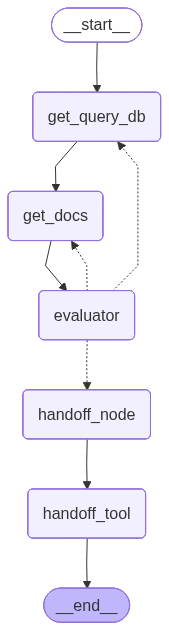

In [198]:
rag_agent_builder = StateGraph(InfoAgentState)

rag_agent_builder.add_node("get_query_db", get_query_db)
rag_agent_builder.add_node("get_docs", get_docs)
rag_agent_builder.add_node("evaluator", evaluator)
rag_agent_builder.add_node("handoff_node", handoff_node)
rag_agent_builder.add_node("handoff_tool", ToolNode([handoff_tool], messages_key="evaluator_logs"))

rag_agent_builder.add_edge(START, "get_query_db")
rag_agent_builder.add_edge("get_query_db", "get_docs")
rag_agent_builder.add_edge("get_docs", "evaluator")
rag_agent_builder.add_conditional_edges("evaluator", decide_next_rag)
rag_agent_builder.add_edge("handoff_node", "handoff_tool")

rag_agent = rag_agent_builder.compile()
display(Image(rag_agent.get_graph().draw_mermaid_png()))

### Invoke Syntax

In [199]:
# query = "What is the training cost of transformer compared to previous models like ConvS2S Ensemble?"
# res = rag_agent.invoke(
#     {
#         "user_query": [query],
#         "agent_logs": [{
#             "name": "PlanReasonAgent",
#             "message": "planned and reasoned, transferring to info agent."
#         }]
#     },
#     config=
#      {
#         "configurable": {
#             "docstore": docstore,
#             "messages_key": "evaluator_logs"
#         }
#     }
# )

# PlanReasonAgent

## PlanReason Prompts

### PlanReason Prompt and Schema

In [234]:
PLANREASON_PROMPT = f"""
    You are the planning, reasoning and supervisor agent in a RAG based QA application.
    You are given the user's question and your job is to think of the valid next steps and decide which agent you need to handoff the task to. You act like the brain behind solving the given task.
    The question can be very complex requiring multiple retrieval steps, code execution, reasoning abilities and web searches. Your job is to properly reason out the problem using available tools.
    After reasoning and using the tools, you have to give the output and tell your reasoning, the next agent that needs to be called in order to solve the user's question and the data you would like to pass on to that agent.

    You are given the following information:
    - The original user query
    - The crafted plan (if there is any plan until now)
    - Chat history of all the agents until now. You can use it to figure out what all has been done up until now and what the next steps are.
    - The extracted docs

    Available Tools:
    - plan_tool: Given a user query, it crafts a plan to address that query. The output is a ordered list of strings that defines the plan.
    - websearch_tool: Given a search string, it searches the web for it and returns the topmost results.
    - handoff_tool: When you think planning and reasoning is done and its time for other agents to work, call this tool to handoff futher tasks to other agents.

    Available Agents:
    - InfoAgent: You can give this agent a simple and context-rich query and it will retrieve the part of document (text chunk, table or image) is requ
    - MathCodingAgent: You can give this agent a mathematical problem and the data to solve that problem, it will write the code to solve it and execute that code without errors and return the final answers
    - SummarizerAgent: After all the required retrieval and calculations are done, this agent can be called and to summarize what all happened and finally give the user the answer to their query.


    Approach:
    - As soon as you receive the user's query and if no plan has been crafted until now i.e the plan array is empty, use the plan tool to create the plan.
    - At every step, recognize what all has been done up until now and where we stand in the proposed plan, carefully reason and when you think it's time to call another agent, you can do that by using the handoff tool
    - for the InfoAgent, the "destination" would be "InfoAgent"
    - for the MathCodingAgent, the "destination" would be "MathCodingAgent"
    - for the SummarizerAgent, the "destination" would be "SummarizerAgent"

    IMPORTANT POINT, How to ask for information from InfoAgent, how to design queries for retrieval
    WHEN CALLING INFO AGENT FOR THE FIRST TIME, pass original query as it is, make no changes.

    When generating agent_args for InfoAgent, prefer formulations that preserve key terms from the original question. Avoid adding speculative conditions unless the original question requires them. The retrieval system works best with concise, literal queries.
    Stick as close to the ORIGINAL USER QUERY as possible. THIS IS VERY IMPORTANT. only make slight modifications if extra data is needed.
    Ask for correct modality, if the original user query asks for numbers or data, then ask for tables. If original query mentions images, charts or figures, then ask for images

    Output Format:
    After your work as the agent is done and it is time to handoff task to other specialised agent, call the handoff tool with the following arguments
    {handoff_tool_args}
    - If you are calling the InfoAgent, pass a query which it can extract documents for.
    - If you are calling the MathCodingAgent, pass a mathematical problem and the data to solve that problem.
    - If you are calling the SummarizerAgent, pass None

"""

### Plan Prompt and Schema

In [235]:
PLAN_PROMPT = """
You are a planning agent in a RAG based QA app.

You are given the following information:
1. The hierarchy of the document from which text, tables and images can be retrieved.
2. The description of all the tools and agents that can be called, what they do and how they respond.
2. The user query. The final thing which needs to be answered.

Your goal:
You have to create a plan for answering the given query. Parse the user’s question carefully. Identify what information is needed to answer it fully.
Determine whether the question requires document retrieval, external web search, data computation, code execution, or just summarisation and which tool is the best for it.
Break down the query into simpler subqueries or tasks. Decide what agents to use and in what order.

Communication Style:
Be explicit in your instructions to other agents. Clearly specify the goal and constraints.

Available Tools / Agents:
- Information Retriever Agent: You can give this agent a simple and context-rich query and it will retrieve the part of document (text chunk, table or image) is requ
- Math and Coding Agent: You can give this agent a mathematical problem and the data to solve that problem, it will write the code to solve it and execute that code without errors and return the final answers
- Summarizer Agent: After all the required retrieval and calculations are done, this agent can be called and to summarize what all happened and finally give the user the answer to their query.

Output Format:
You have to respond in a structured format. Your plan should be a list of strings which is carefully ordered and concise enough to be easily readable.
"""

PLAN_SCHEMA = {
  "title": "PLAN_SCHEMA",
  "description": "A schema to validate the output of planning agent",
  "type": "object",
  "properties": {
      "plan": {
          "description": "A list of strings that defines the plan, is carefully ordered and concise enough to be easily readable.",
          "type": "array",
          "items": {
              "type": "string"
          }
      }
  },
  "required": [
      "plan"
  ]
}
llm_plan = llm.with_structured_output(PLAN_SCHEMA)

## Tools

In [236]:
@tool
def plan_tool(
    user_query: Annotated[str, "the user query for which plan needs to be created"],
    config: RunnableConfig,
    tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """
    This is the plan tool. Given a user query, it crafts a plan to address that query. The output is a ordered list of strings that defines the plan.
    """
    doc_hierarchy = json.dumps(config.get("configurable", {})["docstore"].doc_hierarchy, indent=4)
    messages = [SystemMessage(PLAN_PROMPT)]
    messages.append(HumanMessage(content=f"""
        Document Hierarchy: {doc_hierarchy}
        User Query: {user_query}
    """))

    plan = llm_plan.invoke(messages)
    return Command(update={
        "planreason_logs": [f"Used plan tool to create the plan to solve user query. Here's the plan: {json.dumps(plan['plan'], indent=4)}"],
        "planreason_history": [ToolMessage("Success", tool_call_id=tool_call_id)],
        "plan": plan["plan"]
    })

In [237]:
planreason_tools = [plan_tool, handoff_tool]
llm_planreason = llm.bind_tools(planreason_tools, parallel_tool_calls=False)
def planreason_assistant(state):
    messages = state["planreason_history"]
    new_messages = []
    if not state["planreason_history"]:
        new_messages.append(SystemMessage(PLANREASON_PROMPT))

    extracted_doc_summaries = []
    for doc in state.get("retrieved_docs", []):
        if doc["doc_type"] == "image":
            extracted_doc_summaries.append({"doc_type": "image", "image_summary": doc["image_summary"]})
        if doc["doc_type"] == "table":
            extracted_doc_summaries.append({"doc_type": "table", "table_data": doc["table_data"]})
        else:
            extracted_doc_summaries.append({"doc_type": "text", "text_data": doc["text_data"]})

    new_messages.append(HumanMessage(f"""
    The original user query: {state["original_user_query"]}
    The crafted plan (if there is any plan until now): {json.dumps(state.get("plan"), indent=4)}
    Chat history of all the agents: {json.dumps(state.get("agent_logs"), indent=4)}
    The extracted documents are: {json.dumps(extracted_doc_summaries, indent=4)}
    """))
    res = llm_planreason.invoke(messages + new_messages)

    return_dict = {
        "planreason_logs": [f"plan reasoning agent reasoned following: {res.additional_kwargs.get('reasoning_content'), ''}"],
        "planreason_history": new_messages + [res]
    }

    if res.additional_kwargs.get("tool_calls"):
        if res.additional_kwargs.get("tool_calls")[0]["function"]["name"] == "handoff_tool":
            aimessages = [m for m in state["planreason_history"] if isinstance(m, AIMessage) or isinstance(m, ToolMessage)]
            return_dict["chat_history"] = [{
                "name": "PlanReasonAgent",
                "messages": aimessages
            }]
            return_dict["agent_logs"] = [{
                "name": "PlanReasonAgent",
                "message": " ".join(state["planreason_logs"])
            }]
    return return_dict

## Graph

### State

In [238]:
class PlanReasonAgentState(TypedDict):
    original_user_query: str
    chat_history: Annotated[list[AnyMessage], add]
    agent_logs: Annotated[list[dict], add]
    current_agent: dict
    plan: list[str]
    retrieved_docs: Annotated[list[any], add]

    planreason_history: Annotated[list[AnyMessage], add]
    planreason_logs: Annotated[list[str], add]

### Builder

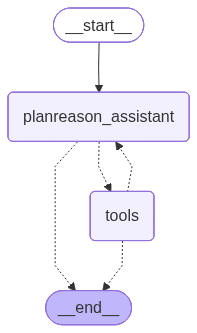

In [239]:
planreason_agent_builder = StateGraph(PlanReasonAgentState)

planreason_agent_builder.add_node("planreason_assistant", planreason_assistant)
planreason_agent_builder.add_node("tools", ToolNode(planreason_tools, messages_key="planreason_history"))

def tool_router(state) -> Literal["tools", "__end__"]:
    return tools_condition(state, messages_key="planreason_history")

def end_router(state) -> Literal["planreason_assistant", "__end__"]:
    if state["planreason_history"][-1].name == "handoff_tool":
        return "__end__"
    return "planreason_assistant"

planreason_agent_builder.add_edge(START, "planreason_assistant")
planreason_agent_builder.add_conditional_edges("planreason_assistant", tool_router)
planreason_agent_builder.add_conditional_edges("tools", end_router)

planreason_agent = planreason_agent_builder.compile()
display(Image(planreason_agent.get_graph().draw_mermaid_png()))

### Invoke Syntax

In [240]:
# res = planreason_agent.invoke(
#     {
#         "original_user_query": "What is the training cost of transformer compared to previous models like ConvS2S Ensemble?"
#     }
#     config=
#     {
#         "configurable": {
#             "docstore": docstore,
#             "messages_key": "planreason_history"
#         }
#     }
# )

# SummarizerAgent

## Summarizer Prompts

In [216]:
SUMMARIZER_PROMPT = """
You are the summarizer agent in a RAG based QA application.
You are given the following information
- The original user query
- The plan crafted to answer that query
- The retrieved documents to answer that query
- The logs of each agent involved in the process and what they have done till now.

Your goal is to find meaningful insights from the data and calculations that can help answer the user's query.
Reply back in a detailed and informative way.
Understand the agent logs, reasoning, retrieval and maths and provide the user a level of transparency in how you reached that answer.
Try to be direct with your answers focussing specifically on what the user has asked
"""

## Tools

In [217]:
llm_multimodal = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")

def summarize_tool(original_user_query, plan, retrieved_docs, agent_logs):
    messages = [SystemMessage(SUMMARIZER_PROMPT)]
    retrieved_images = []
    retrieved_tables = []
    retrieved_texts = []
    for doc in retrieved_docs:
        if doc["doc_type"] == "image":
            retrieved_images.append(doc["image_data"])
        if doc["doc_type"] == "table":
            retrieved_tables.append(doc["table_data"])
        else:
            retrieved_texts.append(doc["text_data"])
    messages.append(HumanMessage(
        f"""
        The original user query: {original_user_query}
        The plan crafted to answer that query: {json.dumps(plan, indent=4)}
        The text chunks retrieved to answer that query: {json.dumps(retrieved_texts, indent=4)}
        The tables retrieved to answer that query: {json.dumps(retrieved_tables, indent=4)}
        The images retrieved are attached below:
        The agent logs and what they have done till now: {json.dumps(agent_logs, indent=4)}
        """
    ))
    for i in retrieved_images:
        messages.append(HumanMessage(content=[
            {
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{i}"},
            }
        ]))
    res = llm_multimodal.invoke(messages)
    return res

# MathCodingAgent

# Parent Graph

## State

In [218]:
class ParentGraphState(TypedDict):
    original_user_query: str
    chat_history: list[dict]
    agent_logs: list[dict]
    current_agent: dict
    plan: list[str]
    retrieved_docs: Annotated[list[any], add]
    final_answer: str

## Tools

In [209]:
def info_agent_node(state, config):
    query = state["current_agent"]["args"]
    docstore = config["configurable"]["docstore"]
    res = rag_agent.invoke(
        {
            "original_user_query": state["original_user_query"],
            "user_query": [query],
            "chat_history": state["chat_history"],
            "agent_logs": state["agent_logs"],
            "current_agent": state["current_agent"],
            "plan": state["plan"]
        },
        config=
         {
            "configurable": {
                "docstore": docstore,
                "messages_key": "evaluator_logs"
            }
        }
    )
    return {
        "chat_history": res["chat_history"],
        "agent_logs": res["agent_logs"],
        "current_agent": res["current_agent"],
        "retrieved_docs": res["retrieved_docs"]
    }

In [241]:
def planreason_agent_node(state, config):
    docstore = config["configurable"]["docstore"]
    res = planreason_agent.invoke(
        {
            "original_user_query": state["original_user_query"],
            "chat_history": state["chat_history"],
            "agent_logs": state["agent_logs"],
            "current_agent": state["current_agent"],
            "plan": state["plan"],
            "retrieved_docs": state["retrieved_docs"]
        },
        config=
        {
            "configurable": {
                "docstore": docstore,
                "messages_key": "planreason_history"
            }
        }
    )
    return {
        "chat_history": res["chat_history"],
        "agent_logs": res["agent_logs"],
        "current_agent": res["current_agent"],
        "plan": res["plan"]
    }

In [230]:
def summarizer_node(state, config):
    res = summarize_tool(
        state["original_user_query"],
        state["plan"],
        state["retrieved_docs"],
        state["agent_logs"]
    )


    return {
        "chat_history": state["chat_history"] + [{"name": "SummarizerAgent", "messages": [res]}],
        "agent_logs": state["agent_logs"] + [{"name": "SummarizerAgent", "message": "The summarizer finalized the answer"}],
        "current_agent": {
            "name": "__end__"
        },
        "final_answer": res.content
    }

## Builder

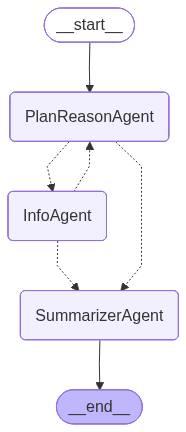

In [242]:
parentgraph_builder = StateGraph(ParentGraphState)

parentgraph_builder.add_node("InfoAgent", info_agent_node)
parentgraph_builder.add_node("PlanReasonAgent", planreason_agent_node)
parentgraph_builder.add_node("SummarizerAgent", summarizer_node)

def router(state):
    return state["current_agent"]["name"]

parentgraph_builder.add_edge(START, "PlanReasonAgent")
parentgraph_builder.add_conditional_edges("PlanReasonAgent", router, ["InfoAgent", "SummarizerAgent"])
parentgraph_builder.add_conditional_edges("InfoAgent", router, ["PlanReasonAgent", "SummarizerAgent"])
parentgraph_builder.add_edge("SummarizerAgent", "__end__")

parentgraph = parentgraph_builder.compile()
display(Image(parentgraph.get_graph().draw_mermaid_png()))


# Test

In [ ]:
docstore = Docstore("report.pdf")
docstore.create_headings_store()

In [243]:
query = "What is the type of positional encoding used? Why is it defined the way it is defined?"
res = parentgraph.invoke(
    {
        "original_user_query": query,
        "chat_history": [],
        "agent_logs": [],
        "current_agent": {},
        "plan": [],
        "retrieved_docs": []
    },
    config=
    {
        "configurable": {
            "docstore": docstore
        }
    }
)

planreason_history
evaluator_logs


In [244]:
for c in res["agent_logs"]:
    print("-----------------------")
    print(c["name"])
    print(c["message"])

-----------------------
PlanReasonAgent
plan reasoning agent reasoned following: ('We need to produce a plan if none exists. Use plan_tool. The user query: "What is the type of positional encoding used? Why is it defined the way it is defined?" Likely about a paper. Need to retrieve docs. First step: create plan. Then handoff to InfoAgent? According to approach: if no plan, use plan tool to create plan. So we call plan_tool with user query.', '') Used plan tool to create the plan to solve user query. Here's the plan: [
    "Use Information Retriever Agent with query: retrieve the content of the 'Positional Encoding' subsection under 'Model Architecture' to find the type of positional encoding and its definition.",
    "After retrieval, use Summarizer Agent to extract the specific type (e.g., sinusoidal) and explain why it is defined that way (e.g., to provide explicit position information, enable the model to attend based on relative positions, avoid learned parameters, and generalize 

In [245]:
for c in res["chat_history"]:
    print(c["name"])
    for m in c["messages"]:
        m.pretty_print()

PlanReasonAgent
================================== Ai Message ==================================
Tool Calls:
  plan_tool (fc_5c524292-9de2-4dea-b703-1d874b170ef4)
 Call ID: fc_5c524292-9de2-4dea-b703-1d874b170ef4
  Args:
    user_query: What is the type of positional encoding used? Why is it defined the way it is defined?
================================= Tool Message =================================
Name: plan_tool

Success
HandoffTool
================================= Tool Message =================================

Successfuly transferred to InfoAgent with reasoning The plan requires retrieving information about the type and rationale of positional encoding. According to guidelines, the first InfoAgent query should use the original user question unchanged to retrieve relevant documents.
InfoAgent
================================== Ai Message ==================================

Performed section-level retrieval and extracted sections: Positional Encoding Position-wise Feed-Forward Ne

### subtests


In [52]:
query = "What is the training cost of transformer compared to previous models like ConvS2S Ensemble?"
res = rag_agent.invoke(
    {
        "user_query": [query],
        "agent_logs": [{
            "name": "PlanReasonAgent",
            "message": "planned and reasoned, transferring to info agent."
        }]
    },
    config=
     {
        "configurable": {
            "docstore": docstore,
            "messages_key": "evaluator_logs"
        }
    }
)

yolox_l0.05.onnx:   0%|          | 0.00/217M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

/tmp/ipython-input-111926991.py:20: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  docs = state["query_db"].get_relevant_documents(state["user_query"][-1])


evaluator_logs


In [53]:
res["current_agent"]

{'name': 'SummarizerAgent', 'args': ''}

In [25]:
res.keys()

dict_keys(['chat_history', 'agent_logs', 'current_agent', 'retrieved_docs', 'user_query', 'extracted_docs', 'query_db', 'sections_extracted', 'latest_evaluation', 'evaluator_logs', 'info_logs'])

In [70]:
for c in res["chat_history"]:
    print(c["name"])
    for m in c["messages"]:
        m.pretty_print()

InfoAgent
================================== Ai Message ==================================

Performed section-level retrieval and extracted sections: Model Variations Machine Translation Training Training Data and Batching Performed second level retrieval and extracted 1 documents This is the evaluation of the evaluator for this retrieval: Text retrieved was relevant but lacked quantitative table; request table for precise cost comparison. Performed second level retrieval and extracted 1 documents This is the evaluation of the evaluator for this retrieval: Retrieved table contains training cost metrics for Transformer and ConvS2S Ensemble, satisfying the query.
HandoffTool
================================= Tool Message =================================

Successfuly transferred to SummarizerAgent with reasoning We have retrieved a table summary describing machine translation model comparisons. No specific user query or calculations are pending. The next appropriate step is to summarize 

In [47]:
res["chat"]

[{'name': 'PlanReasonAgent',
  'message': 'planned and reasoned, transferring to info agent.'},
 {'name': 'InfoAgent',
  'message': 'Performed section-level retrieval and extracted sections: Model Variations Machine Translation Training Training Data and Batching Performed second level retrieval and extracted 2 documents This is the evaluation of the evaluator for this retrieval: Docs retrieved were text summaries lacking numeric table; need table with training cost details. Performed second level retrieval and extracted 2 documents This is the evaluation of the evaluator for this retrieval: Retrieved relevant table and supporting text; sufficient to answer query.'},
 {'name': 'SummarizerAgent',
  'message': 'Successfuly handed off with reasoning We have retrieved relevant information about Transformer model BLEU scores and training costs compared to other models. The user likely wants a concise answer summarizing these results. No further calculations are needed, so we can handoff to 

In [50]:
res["chat_history"]

[AIMessage(content='Performed section-level retrieval and extracted sections: Model Variations Machine Translation Training Training Data and Batching Performed second level retrieval and extracted 2 documents This is the evaluation of the evaluator for this retrieval: Docs retrieved were text summaries lacking numeric table; need table with training cost details. Performed second level retrieval and extracted 2 documents This is the evaluation of the evaluator for this retrieval: Retrieved relevant table and supporting text; sufficient to answer query.', additional_kwargs={}, response_metadata={}),
 ToolMessage(content='Successfuly transferred to SummarizerAgent with reasoning We have retrieved relevant information about Transformer model BLEU scores and training costs compared to other models. The user likely wants a concise answer summarizing these results. No further calculations are needed, so we can handoff to the SummarizerAgent to produce the final answer.', tool_call_id='fc_b5

In [99]:
res = planreason_agent.invoke(
    {
        "original_user_query": "What is the training cost of transformer compared to previous models like ConvS2S Ensemble?"
    },
    config=
    {
        "configurable": {
            "docstore": docstore,
            "messages_key": "planreason_history"
        }
    }
)

planreason_history


In [81]:
res.keys()

dict_keys(['original_user_query', 'chat_history', 'agent_logs', 'current_agent', 'plan', 'retrieved_docs', 'planreason_history', 'planreason_logs'])

In [93]:
res["planreason_history"][-2].additional_kwargs.get("tool_calls")[0]["function"]["name"]

'handoff_tool'

In [102]:
for c in res["chat_history"]:
    print("-------------------------------------------------------------")
    print(c["name"])
    for m in c["messages"]:
        m.pretty_print()

-------------------------------------------------------------
PlanReasonAgent
================================== Ai Message ==================================
Tool Calls:
  plan_tool (fc_808c06ca-3182-4a3c-b6b0-c328c068ac21)
 Call ID: fc_808c06ca-3182-4a3c-b6b0-c328c068ac21
  Args:
    user_query: What is the training cost of transformer compared to previous models like ConvS2S Ensemble?
================================= Tool Message =================================
Name: plan_tool

Success
-------------------------------------------------------------
HandoffTool
================================= Tool Message =================================

Successfuly transferred to InfoAgent with reasoning The plan requires first retrieving the training cost details for the Transformer model from the relevant sections of the source document. I will hand off to the InfoAgent with a specific query to fetch that information.


In [103]:
res["agent_logs"]

[{'name': 'PlanReasonAgent',
  'message': 'plan reasoning agent reasoned Used plan tool to create the plan to solve user query. Here\'s the plan: [\n    "Use the Information Retriever Agent to fetch the text (or table) from the \'Training\' section, specifically the \'Hardware and Schedule\' subsection, that describes the training cost (e.g., GPU days, FLOPs, time) of the Transformer model.",\n    "Use the Information Retriever Agent to fetch the text (or table) from the \'Training\' or \'Results\' sections that mentions the training cost of the ConvS2S Ensemble baseline model.",\n    "If the retrieved data contain numeric cost figures, invoke the Math and Coding Agent to calculate a direct comparison (e.g., cost ratio, percentage reduction) between the Transformer and ConvS2S Ensemble.",\n    "Finally, call the Summarizer Agent to combine the retrieved information and the computed comparison into a concise answer to the user\'s query."\n]'},
 {'name': 'InfoAgent',
  'message': 'Succes

In [59]:
res = planreason_agent.invoke(
    {
        "original_user_query": query,
        "chat_history": [],
        "agent_logs": [],
        "current_agent": {},
        "plan": [],
        "retrieved_docs": []
    },
    config=
    {
        "configurable": {
            "docstore": docstore,
            "messages_key": "planreason_history"
        }
    }
)

return_dict =  {
    "chat_history": res["chat_history"],
    "agent_logs": res["agent_logs"],
    "current_agent": res["current_agent"],
    "plan": res["plan"]
}

planreason_history


In [62]:
return_dict["current_agent"]

{'name': 'InfoAgent',
 'args': "Please retrieve the text from the document's 'Training' section, specifically the 'Hardware and Schedule' subsection, that describes the training cost (compute resources, time, monetary cost) of the Transformer model."}